# Digital Twin for HAADF and EDS



### Quick Start Code Cell

In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 11000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"test/{d}/1") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("test/microscope/1"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...


## 1. Connect to devices

In [ ]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"


# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

In [ ]:
scan = tango.DeviceProxy("test/scan/1")
mic_proxy = tango.DeviceProxy("test/microscope/1")

scan.set_timeout_millis(120_000)
mic_proxy.set_timeout_millis(120_000)

## Acquire Simulated Image

Acquire an image from the HAADF detector and visualize it.

[World] Placed 40 particles in 600.0 Å world
Acceleration voltage 200.0kV  => wavelength 2.51pm
Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'float32', 'dwell_time': 1e-06, 'timestamp': 1774543530.84901}


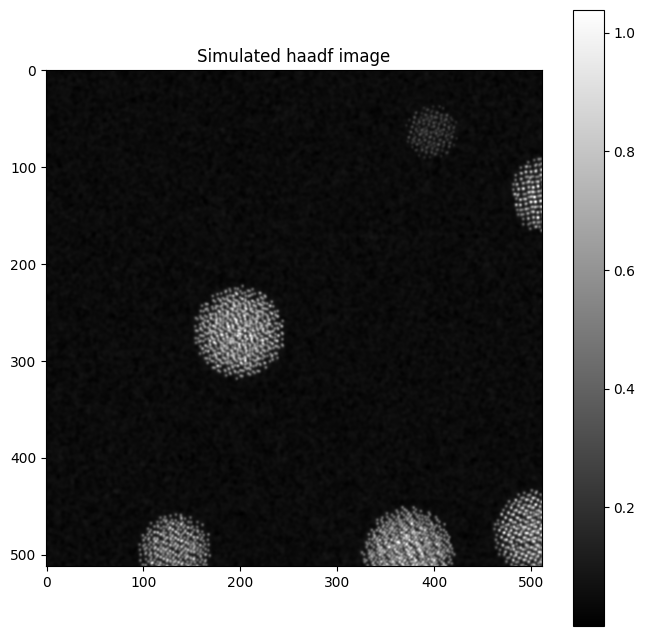

In [5]:
json_meta, raw_bytes = mic_proxy.get_scanned_image()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()

In [13]:
mic_proxy.place_beam([0.36, 0.5])

## Query beam

In [14]:
beam_pos = mic_proxy.beam_pos

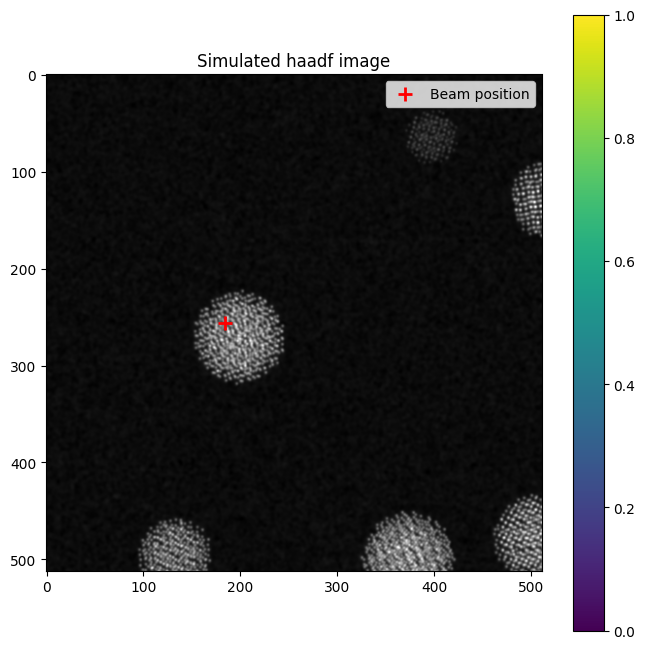

In [15]:
# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = mic_proxy.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {meta['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

## EDS

In [16]:
json_meta, raw_bytes = mic_proxy.get_spectrum('eds')
metadata  = dict(json.loads(json_meta))
spectrum = dict(json.loads(raw_bytes))
spectrum

{'Pt': 1.043956363389652}

In [17]:
# get the stage
starting_position = mic_proxy.get_stage()
print('Stage position:', starting_position)

Stage position: [4.8304588e-07 4.5803887e-07 6.1242787e-07 3.8034278e-07 9.2033463e-07]


In [46]:
# move the stage
move_by = -5e-9 
new_position = starting_position + np.array([move_by, 0, 0, 1, 0])
mic_proxy.move_stage(new_position)

[Stage] pos=[5.43601910e-07 4.22143603e-07 6.15976545e-07 1.00000038e+00
 9.38363144e-07] m  |  view offset=[149.9997704  200.00009576] Å  |  α=0.00°  β=0.00°


Acceleration voltage 200.0kV  => wavelength 2.51pm
Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'float32', 'dwell_time': 1e-06, 'timestamp': 1774543755.491617}


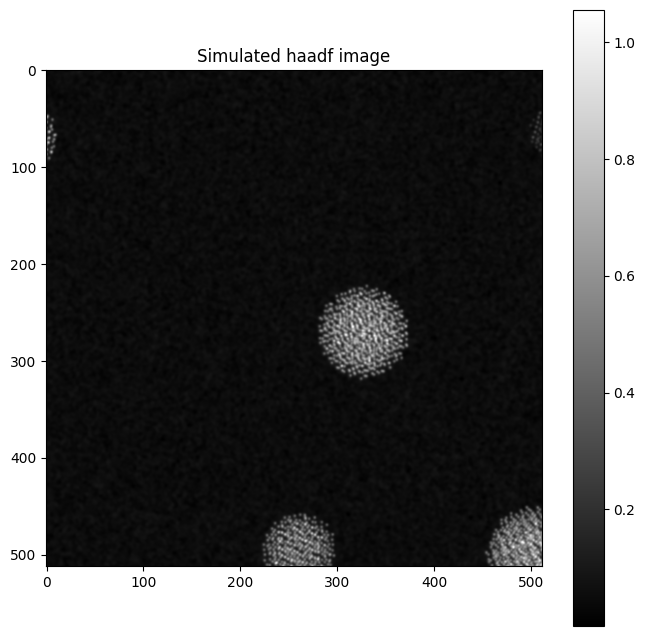

In [47]:
json_meta, raw_bytes = mic_proxy.get_scanned_image()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()